# Log-Odds CRP

> Compute and visualize Lag-CRP curves expressed as log-odds relative to a reference lag.

The log-odds CRP transforms standard conditional response probabilities into
log-odds and subtracts a chosen reference lag to produce baseline-corrected
contiguity curves.  Positive values at a given lag indicate enrichment relative
to the reference; negative values indicate suppression.

$$\text{logit}(p) = \log\!\left(\frac{p}{1-p}\right)$$

$$\Delta\text{LO}(\ell) = \text{logit}\bigl(\text{CRP}(\ell)\bigr) - \text{logit}\bigl(\text{CRP}(\ell_{\text{ref}})\bigr)$$

This representation is especially useful for lists with repeated items, where
raw CRP values can be difficult to interpret due to varying availability.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty to skip) |
| `ylim` | Y-axis limits or `None` for auto |
| `trial_query` | Query string for trial selection |
| `reference_lag` | Lag used as zero-log-odds baseline |
| `max_lag` | Maximum lag to display |
| `epsilon` | Probability clamp for logit |
| `size` | Max study positions per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.log_odds_crp import (
    log_odds_crp,
    plot_log_odds_crp,
    set_false_at_index,
    simple_crp,
    simple_tabulate_trial,
    SimpleTabulation,
    Tabulation,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "log_odds_crp"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
reference_lag = 10
max_lag = 5
epsilon = 1e-6
size = 3

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

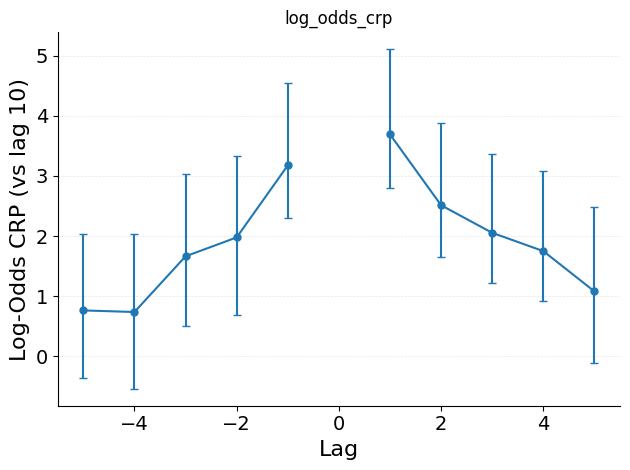

In [5]:
#| code-summary: Plot Log-Odds CRP
#| label: fig-log-odds-crp
#| fig-cap: "Log-odds CRP relative to a distant reference lag."
axis = plot_log_odds_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    reference_lag=reference_lag,
    epsilon=epsilon,
    size=size,
)
axis.set_title(run_tag)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

`plot_log_odds_crp` computes per-subject log-odds CRP curves and displays
the mean with error bounds.  Pass the same dataset with different masks to
compare conditions.

In [6]:
#| echo: false
show_doc(plot_log_odds_crp)

---

### plot_log_odds_crp

>      plot_log_odds_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],j
>                         axcmr.typing.RecallDataset], trial_masks:Union[Sequenc
>                         e[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[
>                         Array,'trial_count']], max_lag:int=5,
>                         color_cycle:Optional[list[str]]=None,
>                         labels:Optional[Sequence[str]]=None,
>                         contrast_name:Optional[str]=None,
>                         axis:Optional[matplotlib.axes._axes.Axes]=None,
>                         reference_lag:int=10, epsilon:float=1e-06, size:int=3,
>                         confidence_level:float=0.95)

*Plot subject-wise Lag-CRP log-odds with error bounds.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Recall datasets to plot. |
| trial_masks | Union |  | Boolean masks selecting trials per dataset. |
| max_lag | int | 5 | Maximum lag to plot. |
| color_cycle | Optional | None | Colors for each dataset. |
| labels | Optional | None | Legend labels for ``datasets``. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Matplotlib Axes to plot on. |
| reference_lag | int | 10 | Lag defining the zero-log-odds baseline. |
| epsilon | float | 1e-06 | Probability clamp for the logit transform. |
| size | int | 3 | Maximum positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the Lag-CRP log-odds plot.** |

`log_odds_crp` returns the full log-odds CRP vector for a single dataset.  It
handles repeated items via the `Tabulation` class.

In [7]:
#| echo: false
show_doc(log_odds_crp)

---

### log_odds_crp

>      log_odds_crp (dataset:jaxcmr.typing.RecallDataset, reference_lag:int=10,
>                    epsilon:float=1e-06, size:int=3)

*Lag-CRP log-odds relative to a reference lag.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| reference_lag | int | 10 | Lag used as the zero-log-odds baseline. |
| epsilon | float | 1e-06 | Probability clamp before the logit transform. |
| size | int | 3 | Maximum positions an item can occupy. |
| **Returns** | **Float[Array, 'lags']** |  | **Log-odds CRP relative to ``reference_lag``.** |

In [8]:
# Log-odds at the reference lag should be zero
trials = jnp.array([[1, 2, 3, 4, 5, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3, 4, 5]], dtype=jnp.int32)
test_dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.array([[5]], dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": trials,
}
result = log_odds_crp(test_dataset, reference_lag=4, size=1)
lag_range = 4  # list_length - 1
ref_idx = 4 + lag_range  # reference_lag + lag_range
assert float(result[ref_idx]) == 0.0

`simple_crp` provides a standard Lag-CRP for lists with no repeated items,
useful as a comparison baseline.

In [9]:
#| echo: false
show_doc(simple_crp)

---

### simple_crp

>      simple_crp (trials:jaxtyping.Integer[Array,'trialsrecall_events'],
>                  list_length:int)

*Lag-CRP across multiple recall trials.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trials | Integer[Array, 'trials recall_events'] | Serial positions in ``1..L`` with ``0`` pads. |
| list_length | int | Study-list length ``L``. |
| **Returns** | **Float[Array, 'lags']** | **CRP of length ``2*L - 1`` indexed by lag offset.** |

In [10]:
# simple_crp produces a vector of length 2*L - 1
trials = jnp.array([[1, 2, 3], [3, 2, 1]], dtype=jnp.int32)
result = simple_crp(trials, list_length=3)
assert result.shape[0] == 5  # 2*3 - 1

### Tabulators

`tabulate_trial` handles a single trial with repeated items;
`simple_tabulate_trial` handles the no-repeat case.

In [11]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      size:int=3)

*Actual and available lags for a single trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall events as study positions. |
| presentation | Integer[Array, 'study_events'] |  | Item identifiers at each study position. |
| size | int | 3 | Maximum positions an item can occupy. |
| **Returns** | **tuple** |  | **Actual and available lag counts.** |

In [12]:
#| echo: false
show_doc(simple_tabulate_trial)

---

### simple_tabulate_trial

>      simple_tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                             list_length:int)

*Lag-CRP tabulation for a single no-repeat trial.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trial | Integer[Array, 'recall_events'] | Serial positions in ``1..L`` with ``0`` pads. |
| list_length | int | Study-list length ``L``. |
| **Returns** | **SimpleTabulation** | **Tabulation tracking actual and available transitions.** |

In [13]:
# Both tabulators agree on lists without repeats
trial = jnp.array([1, 2, 3], dtype=jnp.int32)
presentation = jnp.array([1, 2, 3], dtype=jnp.int32)

simple = simple_tabulate_trial(trial, list_length=3)
actual, avail = tabulate_trial(trial, presentation, size=1)
assert jnp.sum(simple.actual_transitions).item() == jnp.sum(actual).item()

### Utilities

In [14]:
#| echo: false
show_doc(set_false_at_index)

---

### set_false_at_index

>      set_false_at_index (vec:jaxtyping.Bool[Array,'positions'],
>                          i:jaxtyping.Integer[Array,'']|int)

*Set ``vec[i - 1]`` to ``False`` using 1-based indexing.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| vec | Bool[Array, 'positions'] | Boolean vector to modify. |
| i | jaxtyping.Integer[Array, ''] \| int | 1-based index; ``0`` is a no-op sentinel. |
| **Returns** | **tuple** | **Updated vector and ``None``.** |

In [15]:
# 1-based indexing: index 2 clears position 1 (0-based)
vec = jnp.array([True, True, True], dtype=bool)
updated, _ = set_false_at_index(vec, 2)
assert updated.tolist() == [True, False, True]

# Index 0 is a no-op sentinel
unchanged, _ = set_false_at_index(vec, 0)
assert unchanged.tolist() == [True, True, True]